# Setting Up a PhiFlow Smoke Plume as a Dynestyx `DynamicalModel`

`fluid_flow_with_phiflow.ipynb` (in `docs/deep_dives/pde/`) ran the smoke-plume simulation
natively in PhiFlow, with no `dynestyx` involved. This notebook takes the same physics and
wraps it as a proper `dynestyx.DynamicalModel` -- a state-space object with an
`initial_condition`, a `state_evolution`, and an `observation_model` -- so that the rest of
`dynestyx`'s machinery (forward simulation, `Filter`-based inference) can operate on it. This
is the setup step; actual inference (recovering unknown parameters from noisy observations)
is left for a later notebook.

We don't re-derive the physics here -- see `fluid_flow_with_phiflow.ipynb` for the equations
and the PhiFlow quirks we ran into building the `step` function. This notebook is about the
`dynestyx` wiring around it.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import DynamicalModel, Filter, LinearGaussianObservation
from dynestyx.inference.configs.filter import EnKFConfig

from phi.jax import flow

ImportError: cannot import name 'ensemble_kalman_filter' from 'cuthbert.enkf' (unknown location)

## The PhiFlow smoke-plume physics, recapped

Same setup and `step` function as `fluid_flow_with_phiflow.ipynb`: a rising buoyant smoke
plume, advanced by operator splitting (advect smoke, compute buoyancy, advect velocity,
project onto the divergence-free subspace). We use a **much coarser grid** here than in that
notebook -- this notebook's job is to get the `dynestyx` state-space object right, and a
smaller state keeps everything below fast to run and easy to sanity-check, not to produce a
visually detailed simulation.

In [ ]:
domain = flow.Box(x=100, y=100)
inflow = flow.Sphere(x=50, y=9.5, radius=5)
inflow_rate = 0.2

nx, ny = 8, 8    # velocity grid resolution
sx, sy = 16, 16  # smoke grid resolution


def phiflow_step(v, s, p, dt):
    s = flow.advect.mac_cormack(s, v, dt) + inflow_rate * flow.resample(inflow, to=s, soft=True)
    buoyancy = flow.resample(s * (0, 0.1), to=v)
    v = flow.advect.semi_lagrangian(v, v, dt) + buoyancy * dt
    v, p = flow.fluid.make_incompressible(
        v, (), flow.Solve("CG", 1e-3, 1e-4, x0=p, max_iterations=2000)
    )
    return v, s, p

## State representation: flattening PhiFlow fields into a plain vector

`dynestyx` expects the state $x_t$ to be a flat `jax.Array` of shape `(state_dim,)` -- it
knows nothing about PhiFlow `Field` objects. We need an invertible (up to floating point)
map between PhiFlow's native representation and a flat vector.

**One deliberate simplification, flagged rather than hidden:** PhiFlow's native velocity
representation is a `StaggeredGrid` (different numbers of sample points per vector
component, on cell faces rather than cell centers), which does not flatten/unflatten
cleanly into a single rectangular array. We sidestep this by representing velocity as a
**collocated field** -- a vector-valued `CenteredGrid` -- everywhere in this notebook,
rather than a proper staggered grid. PhiFlow's `advect`/`fluid.make_incompressible`
operators accept this without complaint, but it's numerically a weaker choice than a true
MAC grid (collocated velocity-pressure discretizations are prone to checkerboard
pressure-velocity decoupling). This is an acceptable trade for a first inference-ready
prototype; it would be worth revisiting if this state representation needs to support a
higher-fidelity simulation later.

With that choice, both fields flatten trivially:

- Velocity: a `(ny, nx, 2)` array, raveled to `nx*ny*2` scalars.
- Smoke: a `(sy, sx)` array, raveled to `sx*sy` scalars.

concatenated into one flat state vector.

In [3]:
v_dim = nx * ny * 2
s_dim = sx * sy
state_dim_2d = v_dim + s_dim
obs_dim_2d = s_dim  # we will only observe the smoke field, not velocity (see below)
control_dim_2d = 0  # no control inputs in this notebook


def flatten(v, s):
    v_flat = jnp.reshape(v.values.native("y,x,vector"), (v_dim,))
    s_flat = jnp.reshape(s.values.native("y,x"), (s_dim,))
    return jnp.concatenate([v_flat, s_flat])


def unflatten(x):
    v_flat = jnp.reshape(x[:v_dim], (ny, nx, 2))
    s_flat = jnp.reshape(x[v_dim:], (sy, sx))
    v = flow.CenteredGrid(
        flow.math.wrap(v_flat, flow.math.spatial(y=ny, x=nx), flow.math.channel(vector="x,y")),
        0, domain, x=nx, y=ny,
    )
    s = flow.CenteredGrid(
        flow.math.wrap(s_flat, flow.math.spatial(y=sy, x=sx)),
        flow.ZERO_GRADIENT, domain, x=sx, y=sy,
    )
    return v, s

NameError: name 'nx' is not defined

## `state_evolution`: a discrete-time transition, not an ODE

PhiFlow's `step` is fundamentally a **fixed-step discrete map** (as established when we
looked at `phiml.math.iterate`'s source in the earlier PhiFlow notebook), not something with
a continuous-time drift. The right `dynestyx` fit is therefore
`DiscreteStateTransition` -- a callable

```python
state_evolution(x, u, t_now, t_next) -> obj   # obj.sample(key) -> x_next
```

not `ContinuousTimeStateEvolution`/`ODESimulator`. `obj` only needs to support
`.sample(key)` (and `.shape()`, used once by `DynamicalModel`'s constructor to check
dimensions) -- it does not need to be a full NumPyro `Distribution` with `log_prob`,
because we're targeting `EnKFConfig`, which only ever calls `.sample(key)` on the
transition's output (confirmed by reading `dynestyx/inference/integrations/cuthbert/discrete_filter.py`
directly: `d = dynamics.state_evolution(...); d.sample(key)`, with no `.log_prob` or `.mean`
call anywhere on that path).

**A real gotcha worth documenting.** `DynamicalModel.__init__` validates `state_evolution`
by calling it once with a probe state and a *dummy* `t_next = t_now + 1.0`
(`dynestyx/models/checkers.py::_validate_discrete_state_evolution_output_shape`). If our
transition's behavior depended on the literal numeric difference `t_next - t_now` (e.g.
"take `round((t_next-t_now)/dt)` PhiFlow steps"), this validation call would run a
different, dummy-time-implied number of real PhiFlow steps than any real simulation call
would -- silently wrong, or (for very different `dt` values) needlessly expensive. We avoid
this entirely by making `n_substeps` a **fixed constant on the transition object**, not
derived from `t_next - t_now` at all: every call to `state_evolution` advances the state by
exactly `n_substeps` PhiFlow steps of size `dt`, regardless of what `t_now`/`t_next`
literally are. `t_now`/`t_next` remain meaningful as a time axis for plotting, but the
transition's own behavior does not depend on their difference.

In [4]:
class SmokePlumeSample(eqx.Module):
    """The bare sample()/shape() object required by EnKFConfig -- no log_prob needed."""

    loc: jax.Array
    noise_std: float = eqx.field(static=True)

    def sample(self, key):
        return self.loc + self.noise_std * jr.normal(key, self.loc.shape)

    def shape(self):
        return self.loc.shape


class SmokePlumeTransition(eqx.Module):
    """Discrete-time state_evolution: n_substeps fixed PhiFlow steps of size dt."""

    dt: float = eqx.field(static=True)
    n_substeps: int = eqx.field(static=True)
    process_noise_std: float = eqx.field(static=True)

    def __call__(self, x, u, t_now, t_next):
        v, s = unflatten(x)
        p = None  # reset every call: the earlier PhiFlow notebook's jit_compile tracer-leak
                  # bug was specifically triggered by carrying `p` forward across separate
                  # calls -- resetting it here avoids that trigger entirely. `p` is still
                  # warm-started across the *inner* n_substeps loop below, within one call.
        for _ in range(self.n_substeps):
            v, s, p = phiflow_step(v, s, p, self.dt)
        loc = flatten(v, s)
        return SmokePlumeSample(loc=loc, noise_std=self.process_noise_std)


dt_phiflow = 0.5      # PhiFlow's own internal step size
n_substeps = 2         # PhiFlow steps taken per dynestyx transition (physical time per
                        # transition = dt_phiflow * n_substeps = 1.0)

state_evolution = SmokePlumeTransition(
    dt=dt_phiflow, n_substeps=n_substeps, process_noise_std=1e-3
)

## `observation_model` and `initial_condition`

We observe the **smoke field only** -- not velocity, and (as established when we worked
through EnKF for this kind of simulator) definitely not pressure, which was never part of
the state vector at all. `H` picks out the smoke block of the flattened state and zeroes
out the velocity block; `LinearGaussianObservation` (dynestyx's built-in, unchanged from the
other PDE notebooks) does the rest.

The initial condition mirrors the earlier notebook's `v0 = 0, smoke0 = 0` (quiescent domain,
smoke rises from the inflow once the simulation starts) -- unlike the toy template's
arbitrary nonzero mean, `[3.0, 2.0]`, zero is the physically correct starting point here. The
small covariance represents residual initialization uncertainty rather than a genuinely
informative distribution.

In [5]:
H = jnp.concatenate([jnp.zeros((obs_dim_2d, v_dim)), jnp.eye(s_dim)], axis=1)
observation_model = LinearGaussianObservation(H=H, R=0.05**2 * jnp.eye(obs_dim_2d))

initial_condition = dist.MultivariateNormal(
    loc=jnp.zeros(state_dim_2d), covariance_matrix=1e-6 * jnp.eye(state_dim_2d)
)

NameError: name 'obs_dim_2d' is not defined

## Putting it together: the `DynamicalModel`

This mirrors the template exactly -- `initial_condition`, `state_evolution`,
`observation_model`, `control_dim` -- with each placeholder replaced by the smoke-plume
pieces built above. Constructing this runs `dynestyx`'s validation probe described above
(one real call to `state_evolution`, with `n_substeps` fixed PhiFlow steps -- cheap and
deterministic, not dependent on the dummy probe time).

In [7]:
dynamics = DynamicalModel(
    initial_condition=initial_condition,
    state_evolution=state_evolution,
    observation_model=observation_model,
    control_dim=control_dim_2d,
)

print("state_dim:", dynamics.state_dim, " observation_dim:", dynamics.observation_dim)

/opt/anaconda3/envs/dynestyx/lib/python3.13/site-packages/phi/physics/fluid.py:156: RuntimeWarning: Rank deficiency >= 1 detected in linear solve. Matrix might be singular which can lead to convergence problems. Please specify using Solve(rank_deficiency=...).
  pressure = math.solve_linear(masked_laplace, div, solve, velocity.boundary, hard_bcs, active, wide_stencil=wide_stencil, order=order, implicit=None, upwind=None, correct_skew=correct_skew)


state_dim: 384  observation_dim: 256


## Discrete iteration: forward simulation

We use `dsx.simulate(...)` -- the pure-JAX, NumPyro-free entry point -- rather than
`ODESimulator`/`SDESimulator`: there is no solver configuration to pick, because there is no
ODE here. Each of the `len(predict_times) - 1` transitions between requested times calls
`state_evolution` once, which (per the design above) always advances the state by exactly
`n_substeps` PhiFlow steps of size `dt`. `predict_times` therefore doesn't need to match
`dt`/`n_substeps` numerically at all -- it's just how many transitions to take and what time
labels to attach to them.

In [8]:
n_steps = 8
predict_times = jnp.arange(n_steps, dtype=jnp.float64)

result = dsx.simulate(dynamics, rng_key=jr.PRNGKey(0), predict_times=predict_times, n_simulations=1)

print("states shape:", result.states.shape, " observations shape:", result.observations.shape)
print("any nan:", bool(jnp.any(jnp.isnan(result.states))))

states shape: (1, 8, 384)  observations shape: (1, 8, 256)
any nan: False


## Visualizing the solution

Same snapshot-grid style as `fluid_flow_with_phiflow.ipynb`, unpacking the smoke block of
the flattened state back into a `(sy, sx)` image at each saved time.

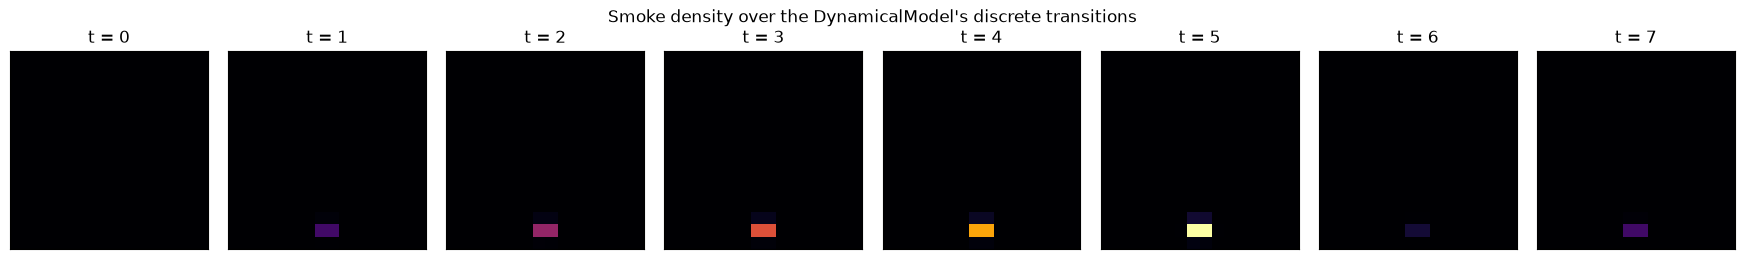

In [9]:
smoke_traj = np.asarray(result.states[0, :, v_dim:]).reshape(n_steps, sy, sx)

fig, axes = plt.subplots(1, n_steps, figsize=(2.2 * n_steps, 2.6))
vmax = smoke_traj.max()
for ax, t_idx in zip(axes, range(n_steps)):
    ax.imshow(smoke_traj[t_idx], origin="lower", extent=(0, 100, 0, 100), cmap="inferno", vmin=0, vmax=vmax)
    ax.set_title(f"t = {t_idx}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Smoke density over the DynamicalModel's discrete transitions")
plt.tight_layout()
plt.show()

## Sanity check: is this actually ready for `Filter`-based inference?

This is deliberately not a real inference run -- no unknown parameter is being recovered,
and `n_particles=16` is far too small an ensemble for this ~400-dimensional state to give
trustworthy uncertainty estimates (see the earlier note on EnKF for operator-split
Navier-Stokes-type simulators: rank-deficiency, inflation/localization, and ensemble-size
considerations all still apply here). The point of this cell is narrower: confirm that the
`SmokePlumeTransition`/`SmokePlumeSample` objects built above actually satisfy the contract
`EnKFConfig` needs, end to end, by running `Filter` on synthetic observations generated from
the forward simulation above and checking we get back a finite marginal log-likelihood.

In [10]:
obs_values = result.observations[0]  # (n_steps, obs_dim_2d)

with Filter(filter_config=EnKFConfig(n_particles=16)):
    filtered = dsx.condition("f", dynamics, obs_times=predict_times, obs_values=obs_values)

print("marginal_loglik:", float(jnp.asarray(filtered.marginal_loglik)))

marginal_loglik: 2066.710957205079


## What this notebook set up, and what's next

We now have a genuine `dynestyx.DynamicalModel` wrapping the PhiFlow smoke-plume physics:
a flat-vector state representation (with the collocated-velocity simplification flagged
above), a discrete-time `state_evolution` that takes a fixed number of PhiFlow steps per
transition (sidestepping both the `t_next-t_now` validation-probe gotcha and the
`jit_compile` tracer-leak bug from the earlier notebook), and a `LinearGaussianObservation`
over the smoke field only. Forward simulation and a minimal `Filter(EnKFConfig())` call both
run cleanly against it.

Left for later notebooks: actual parameter inference (e.g. recovering the buoyancy
coefficient or inflow rate from noisy observations), a properly-sized ensemble with
inflation/localization, and revisiting the collocated-velocity simplification if a
higher-fidelity state representation turns out to matter.

## Running EnKF for real: filtering a noisy trajectory

The sanity check above only confirmed that `EnKFConfig` runs against this model at all --
it never looked at what the filter actually estimates. Here we run it for real: generate a
synthetic "ground truth" trajectory (which a real assimilation problem wouldn't have access
to, but we keep it here specifically to score the filter against), feed the filter only the
noisy smoke observations, and see how well it reconstructs the full state -- including the
**velocity block, which is never directly observed**.

We use EnKF rather than a particle filter, for the reason already worked out in detail in
the earlier note on data assimilation for operator-split Navier-Stokes-type simulators
(`/Users/matthieu/Documents/Dynestyx/data_assimilation_enkf_for_ns.md`): at
`state_dim=384`, a particle filter's importance weights collapse almost immediately --
`dynestyx`'s own `PFConfig` docstring carries exactly this caveat -- while EnKF, already
wired up above, is the tool actually suited to a state this size.

In [ ]:
n_steps_filter = 12
predict_times_filter = jnp.arange(n_steps_filter, dtype=jnp.float64)

# "Ground truth" -- kept only so we can score the filter; a real assimilation problem
# wouldn't have this.
ground_truth = dsx.simulate(
    dynamics, rng_key=jr.PRNGKey(7), predict_times=predict_times_filter, n_simulations=1
)
true_states = ground_truth.states[0]        # (n_steps_filter, state_dim_2d)
obs_values = ground_truth.observations[0]   # (n_steps_filter, obs_dim_2d) -- smoke only

with Filter(filter_config=EnKFConfig(n_particles=64)):
    filtered = dsx.condition(
        "f", dynamics, obs_times=predict_times_filter, obs_values=obs_values
    )

# filtered.dists is a list of per-time MultivariateNormal posteriors over the full state.
filtered_means = jnp.stack([jnp.asarray(d.mean) for d in filtered.dists])

smoke_rmse = jnp.sqrt(jnp.mean((filtered_means[:, v_dim:] - true_states[:, v_dim:]) ** 2, axis=1))
velocity_rmse = jnp.sqrt(jnp.mean((filtered_means[:, :v_dim] - true_states[:, :v_dim]) ** 2, axis=1))

print("marginal_loglik:", float(jnp.asarray(filtered.marginal_loglik)))
print("smoke RMSE per step (observed block):   ", smoke_rmse)
print("velocity RMSE per step (unobserved block):", velocity_rmse)

In [ ]:
fig, (ax_smoke, ax_vel) = plt.subplots(1, 2, figsize=(10, 3.5))

ax_smoke.plot(predict_times_filter, smoke_rmse, marker="o")
ax_smoke.set_title("Smoke RMSE (observed block)")
ax_smoke.set_xlabel("t")
ax_smoke.set_ylabel("RMSE")

ax_vel.plot(predict_times_filter, velocity_rmse, marker="o", color="tab:red")
ax_vel.set_yscale("log")
ax_vel.set_title("Velocity RMSE (unobserved block) -- note the log scale")
ax_vel.set_xlabel("t")
ax_vel.set_ylabel("RMSE (log scale)")

plt.tight_layout()
plt.show()

In [ ]:
snapshot_indices = [0, n_steps_filter // 3, 2 * n_steps_filter // 3, n_steps_filter - 1]
true_smoke = np.asarray(true_states[:, v_dim:]).reshape(n_steps_filter, sy, sx)
filtered_smoke = np.asarray(filtered_means[:, v_dim:]).reshape(n_steps_filter, sy, sx)
vmax = max(true_smoke.max(), filtered_smoke.max())

fig, axes = plt.subplots(2, len(snapshot_indices), figsize=(2.2 * len(snapshot_indices), 4.6))
for col, t_idx in enumerate(snapshot_indices):
    axes[0, col].imshow(true_smoke[t_idx], origin="lower", extent=(0, 100, 0, 100), cmap="inferno", vmin=0, vmax=vmax)
    axes[0, col].set_title(f"true, t={t_idx}")
    axes[1, col].imshow(filtered_smoke[t_idx], origin="lower", extent=(0, 100, 0, 100), cmap="inferno", vmin=0, vmax=vmax)
    axes[1, col].set_title(f"filtered mean, t={t_idx}")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()